In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl

import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Roboto"]
mpl.rcParams["figure.dpi"] = 100

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 12,
    "axes.titleweight": "regular",
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

In [4]:
def evolve(x0, f, N=1):
  traj = np.zeros((N+1, 4))
  traj[0] = x0
  x = x0

  
  for t in range(1, N+1):
      x = f(x)
      if t % 25 == 0:
        s = 0.1
        c=0.2
        R0 = 1-s/2
        w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
        w_bar = np.dot(x, w)
        
        Ds = (w[0]*w[3]*x[0]*x[3] - w[1]*w[2]*x[1]*x[2]) / w_bar**2
        print(f"LD at {t}: {x[0]*x[3]-x[1]*x[2]:.6f}")
        print(f"Expected LD: {(1-c)*Ds:.6f}\n")
        
      traj[t] = x
  return traj

def plot_traj(traj, N_gen):
    generations = np.arange(traj.shape[0])
    labels = [r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$"]
    colors = ['navy', 'forestgreen', 'purple', 'crimson']

    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    for i in range(4):
        plt.plot(generations, traj[:, i], label=labels[i], color=colors[i], alpha=1)

    plt.legend()
    plt.show()

def evolve_traj(f, x_init=np.zeros(4), N_gen=2000):
  traj = evolve(x_init, f, N_gen)
  plot_traj(traj, N_gen)
  return traj

LD at 25: 0.025133
Expected LD: 0.024478

LD at 50: 0.008753
Expected LD: 0.008215

LD at 75: 0.001066
Expected LD: 0.000961

LD at 100: 0.000061
Expected LD: 0.000054

LD at 125: 0.000003
Expected LD: 0.000002

LD at 150: 0.000000
Expected LD: 0.000000

LD at 175: 0.000000
Expected LD: 0.000000

LD at 200: 0.000000
Expected LD: 0.000000

LD at 225: 0.000000
Expected LD: 0.000000

LD at 250: 0.000000
Expected LD: 0.000000

LD at 275: 0.000000
Expected LD: 0.000000

LD at 300: 0.000000
Expected LD: 0.000000

LD at 325: 0.000000
Expected LD: 0.000000

LD at 350: 0.000000
Expected LD: 0.000000

LD at 375: 0.000000
Expected LD: 0.000000

LD at 400: 0.000000
Expected LD: 0.000000

LD at 425: 0.000000
Expected LD: 0.000000

LD at 450: 0.000000
Expected LD: 0.000000

LD at 475: 0.000000
Expected LD: 0.000000

LD at 500: 0.000000
Expected LD: 0.000000

LD at 525: 0.000000
Expected LD: 0.000000

LD at 550: 0.000000
Expected LD: 0.000000

LD at 575: 0.000000
Expected LD: 0.000000

LD at 600: 0.0

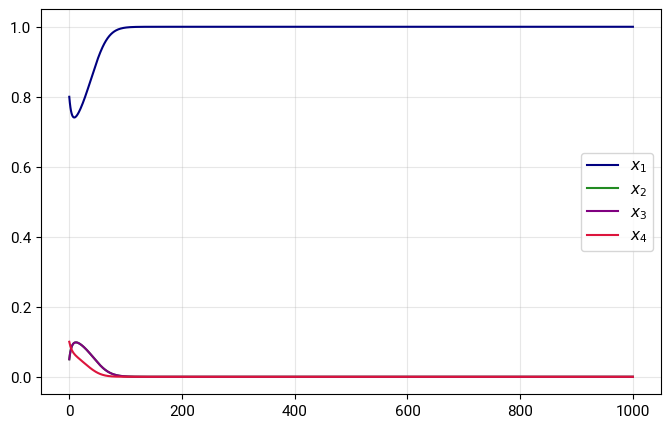

In [5]:
def f(x):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w)
  
  c = 0.2

  x_prime = np.zeros(4)
  for i in range(4):
    sgn = -1 if i==0 or i==3 else 1
    x_prime[i] = x[i]*w[i]/w_bar + sgn * c * (w[0]*w[3]*x[0]*x[3] - w[1]*w[2]*x[1]*x[2]) / (w_bar)**2
  
  return x_prime

x1 = 0.8
x4 = 0.1
x2 = (1 - x1 - x4) / 2
x3 = x2
x_init = np.array([x1, x2, x3, x4])
traj = evolve_traj(f, x_init, 1000)


s = 0.1
R0 = 1-s/2
w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
# epi = w[0]+w[3]-w[1]-w[2]
# c = 0.2
# print(f"Expected QLE: {epi / c}")

## Streamflow

/Users/chasevanamburg/miniforge3/envs/mf/lib/python3.13/site-packages/matplotlib/patches.py:3436: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


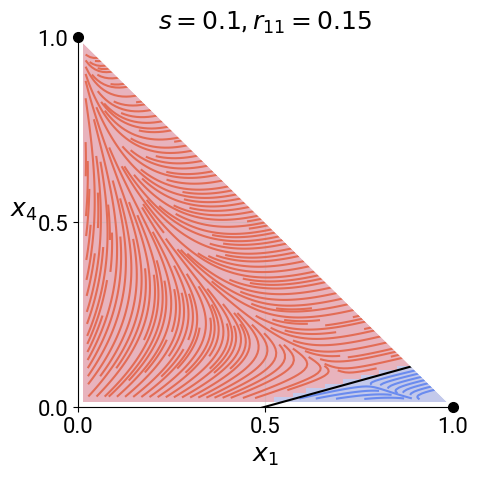

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.patches import Polygon


def f(x):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w)
  
  c = 0.15

  x_prime = np.zeros(4)
  for i in range(4):
    sgn = -1 if i==0 or i==3 else 1
    x_prime[i] = x[i]*w[i]/w_bar + sgn * c * (w[0]*w[3]*x[0]*x[3] - w[1]*w[2]*x[1]*x[2]) / (w_bar)**2
  
  return x_prime

def evolve(x0, f, N=300):
  traj = np.zeros((N+1, 4))
  traj[0] = x0
  x = x0

  for t in range(1, N+1):
      x = f(x)
      traj[t] = x

  return traj

init_points = [ ]
grid = np.linspace(0.05, 0.95, 19)
for x1 in grid:
    for x4 in grid:
        if x1+x4 <= 1:
            x2 = (1-x1-x4)/2
            x3 = x2
            x = np.array([x1, x2, x3, x4])
            init_points.append(x)
final_points = np.array([evolve(x, f)[-1] for x in init_points])
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0).fit(np.array([final_points[:, 0], final_points[:, 3]]).T)
centers = kmeans.cluster_centers_


n = 80
x1_flat = np.linspace(0.02, 0.98, n)
x4_flat = x1_flat.copy()
x1s, x4s = np.meshgrid(x1_flat, x4_flat)
mask = (x1s + x4s) <= 1.0
x1s_masked = np.ma.masked_where(~mask, x1s)
x4s_masked = np.ma.masked_where(~mask, x4s)

delta_x1 = np.zeros_like(x1s)
delta_x4 = np.zeros_like(x4s)

basin_labels = np.zeros_like(x1s, dtype=int)

for i in range(n):
    for j in range(n):
        x1, x4 = x1s[i, j], x4s[i, j]
        x2 = (1 - x1 - x4) / 2
        x3 = x2
        x = np.array([x1, x2, x3, x4])
        x_prime = f(x)
        delta_x1[i, j] = x_prime[0] - x1
        delta_x4[i, j] = x_prime[3] - x4
        
        x_f = evolve(x, f, N=100)[-1]
        basin_labels[i, j] = kmeans.predict([[x_f[0], x_f[3]]])[0]


fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_4$", rotation=0, labelpad=10)
ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
ax.grid(True, alpha=0.3)

basin_labels = 1 - basin_labels
ax.pcolormesh(x1s, x4s, basin_labels, cmap="coolwarm", shading="auto", alpha=0.3, vmin=0, vmax=1)
color_map = [plt.cm.coolwarm(0.15), plt.cm.coolwarm(0.85)]

for label, color in enumerate(color_map):
    delta_x1_masked = np.ma.masked_where(basin_labels != label, delta_x1)
    delta_x4_masked = np.ma.masked_where(basin_labels != label, delta_x4)
    # delta_x1_masked = np.ma.masked_where(~mask, delta_x1_masked)
    # delta_x4_masked = np.ma.masked_where(~mask, delta_x4_masked)

    strm = ax.streamplot(x1s, x4s, delta_x1_masked, delta_x4_masked, color=color, density=3, linewidth=1.5, arrowsize=0, integration_direction="forward")
    triangle = Polygon(
        [(0, 0), (1, 0), (0, 1)],
        closed=True,
        transform=ax.transData
    )
    strm.lines.set_clip_path(triangle)
    strm.arrows.set_clip_path(triangle)
    ax.fill(
        [0, 1, 1],
        [1, 0, 1],
        color="white",
        zorder=3
    )

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 14,
    "axes.titleweight": "regular",
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

ax.plot(centers[:, 0], centers[:, 1], 'ko', markersize=7, label="Equilibria", clip_on=False, zorder=4) # centers[1:, 0], centers[1:, 1]
x = np.array([0.35, 0.75])
y = 0.7*(x-0.35)


x = np.array([0.35, 0.85])
y = 0.38*x - 0.16

x = np.array([0.35, 0.9])
y = 0.28*x - 0.14

ax.plot(x, y, 'k-')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title(r"$s=0.1$, $r_{11}=0.15$"); plt.tight_layout(); plt.show()
